In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_url = pd.read_csv('/home/ancientsoftware/iot-threat-detector/data/phishing_site_urls.csv')

print(df_url.shape)
print(df_url.columns.tolist())
print(df_url['Label'].value_counts())
df_url.head()

(549346, 2)
['URL', 'Label']
Label
good    392924
bad     156422
Name: count, dtype: int64


,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [3]:
import os
print(os.getcwd())

/home/ancientsoftware/iot-threat-detector


In [4]:
df_url['url_length'] = df_url['URL'].str.len()
df_url['num_dots'] = df_url['URL'].str.count(".")
df_url[['URL', 'url_length', 'num_dots']].head()

,URL,url_length,num_dots
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,225,225
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,81,81
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,177,177
3,mail.printakid.com/www.online.americanexpress....,60,60
4,thewhiskeydregs.com/wp-content/themes/widescre...,116,116


In [5]:
df_url['num_hyphens'] = df_url['URL'].str.count("-")
df_url[['URL','num_hyphens']].head()

,URL,num_hyphens
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,4
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,2
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,1
3,mail.printakid.com/www.online.americanexpress....,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,1


In [6]:
df_url['URL'].str.split('.').head()

0    [nobell, it/70ffb52d079109dca5664cce6f31737378...
1    [www, dghjdgf, com/paypal, co, uk/cycgi-bin/we...
2    [serviciosbys, com/paypal, cgi, bin, get-into,...
3    [mail, printakid, com/www, online, americanexp...
4    [thewhiskeydregs, com/wp-content/themes/widesc...
Name: URL, dtype: object

In [7]:
df_url['TLD'] = df_url['URL'].str.split('.').str[-1]
df_url[['URL', 'TLD']].head()

,URL,TLD
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,1&login_access=1322408526
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,php
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,dispatch35463256rzr321654641dsf654321874/href/...
3,mail.printakid.com/www.online.americanexpress....,html
4,thewhiskeydregs.com/wp-content/themes/widescre...,com/wp-content/themes/widescreen/includes/temp...


In [8]:
import math
from collections import Counter

def calculate_entropy(string):
    counts = Counter(string)
    length = len(string)
    probabilities = [count / length for count in counts.values()]
    entropy = -sum(p * math.log2(p) for p in probabilities)
    return entropy

In [9]:
df_url['entropy'] = df_url['URL'].apply(calculate_entropy)

In [10]:
df_url['TLD'].nunique()

282403

In [11]:
df_url[['URL', 'TLD']].sample(10)

,URL,TLD
492877,10mayo.411officesupply.com/forums/viewtopic.ph...,y7145366ct865yka3
95719,www.1up.com/do/previewPage?cId=3150826&amp;did=1,com/do/previewPage?cId=3150826&amp;did=1
547959,webdav1.storegate.com/ordu1337/home/ordu1337,com/ordu1337/home/ordu1337
190945,freepages.genealogy.rootsweb.ancestry.com/~rft...,html
514420,rep.inandoutand.in/a,in/a
91763,www.eblong.com/zarf/werewolf.html,html
483065,sites.google.com/site/sportblognews/watch-wolv...,com/site/sportblognews/watch-wolverhampton-wan...
460889,vivianalexander.com/,com/
7743,www.lesaem.org/dyn/news/documents/pl/www.paypa...,php?cmd=?cmd=_login&amp;dispatch=5885d80a13c0d...
357795,imdb.com/name/nm0002107/,com/name/nm0002107/


In [12]:
df_url['domain'] = df_url['URL'].str.split('/').str[0]

In [13]:
df_url[['URL', 'domain']].sample(10)

,URL,domain
136796,artemusgroupusa.com/wp-content/uploads/elebaba...,artemusgroupusa.com
466541,worthpoint.com/worthopedia/darlene-gillespie-t...,worthpoint.com
382725,manta.com/c/mm7fk98/san-antonio-park-head-start,manta.com
544536,raycon.ph/873nf3g,raycon.ph
169737,en.parkopedia.ca/parking/private/outdoor_parki...,en.parkopedia.ca
180193,en.wikipedia.org/wiki/Rufus_Jones,en.wikipedia.org
229866,pipl.com/directory/tags/Rossy,pipl.com
23944,'1pcables-inox.com/index.php?amp;e=ian+at+vans...,'1pcables-inox.com
49413,www.chacramusic.com/homepage.htm,www.chacramusic.com
244450,suicidegirls.com/girls/Discordia/photos/+Nothi...,suicidegirls.com


In [14]:
df_url['TLD'] = df_url['domain'].str.split('.').str[-1]

In [15]:
df_url['TLD'].nunique()

1580

In [16]:
df_url['TLD'].value_counts().head(20)

TLD
com     361588
org      48628
net      23432
ca       10886
edu      10060
uk        8479
ru        6190
info      4366
br        4113
au        4081
de        3182
gov       3038
pl        2686
biz       2319
in        2185
it        2113
us        1851
cn        1800
fr        1747
mx        1508
Name: count, dtype: int64

In [17]:
top_tlds = df_url['TLD'].value_counts().head(15).index
df_url['TLD_grouped'] = df_url['TLD'].apply(lambda x: x if x in top_tlds else 'other')

In [18]:
df_url['TLD_grouped'].value_counts()

TLD_grouped
com      361588
other     54113
org       48628
net       23432
ca        10886
edu       10060
uk         8479
ru         6190
info       4366
br         4113
au         4081
de         3182
gov        3038
pl         2686
biz        2319
in         2185
Name: count, dtype: int64

In [19]:
df_encoded = pd.get_dummies(df_url, columns=['TLD_grouped'], prefix='tld')

In [20]:
df_encoded.columns.tolist()

['URL',
 'Label',
 'url_length',
 'num_dots',
 'num_hyphens',
 'TLD',
 'entropy',
 'domain',
 'tld_au',
 'tld_biz',
 'tld_br',
 'tld_ca',
 'tld_com',
 'tld_de',
 'tld_edu',
 'tld_gov',
 'tld_in',
 'tld_info',
 'tld_net',
 'tld_org',
 'tld_other',
 'tld_pl',
 'tld_ru',
 'tld_uk']

In [21]:
tld_cols = [col for col in df_encoded.columns if col.startswith('tld_')]
feature_cols = ['url_length', 'num_dots', 'num_hyphens', 'entropy'] + tld_cols
print(feature_cols)

['url_length', 'num_dots', 'num_hyphens', 'entropy', 'tld_au', 'tld_biz', 'tld_br', 'tld_ca', 'tld_com', 'tld_de', 'tld_edu', 'tld_gov', 'tld_in', 'tld_info', 'tld_net', 'tld_org', 'tld_other', 'tld_pl', 'tld_ru', 'tld_uk']


In [22]:
X = df_encoded[feature_cols]
y = df_encoded['Label']

In [23]:
print(X.shape)
print(y.shape)

(549346, 20)
(549346,)


In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
print(X_train.shape)
print(X_test.shape)

(439476, 20)
(109870, 20)


In [29]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

The model performs noticiably better on legitimate URLs (91% recall) than phishing URLs (63% recall). This is due to well crafted phishing links being created to appear structually similar to legitimate URLs. Features like length, dot count, and TLD (Top Level Domain) have less power against sophicated attacks. This mirriors current security challenges because even human users struggle to visually distinguish between good and bad URLs. Future improvements could include analyzing actual page content, registration age of the domain, or SSL certificate details instead of solely relying on URL structure.

In [32]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[19737 11463]
 [ 6928 71742]]


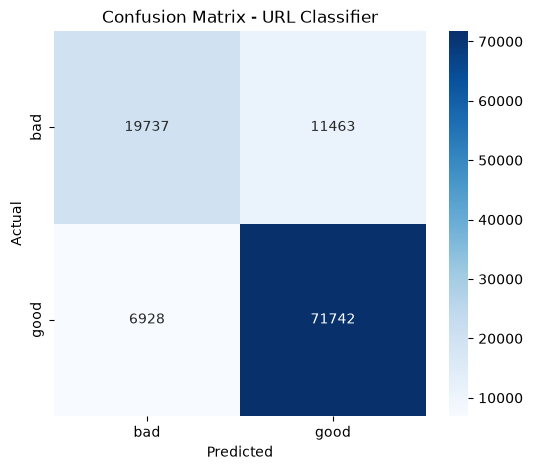

In [34]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['bad', 'good'], yticklabels=['bad', 'good'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - URL Classifier')
plt.show()

In [35]:
importances = pd.Series(model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)
print(importances)

entropy        0.398210
tld_other      0.152656
num_dots       0.085380
url_length     0.085184
num_hyphens    0.070992
tld_com        0.042068
tld_ru         0.033775
tld_org        0.025423
tld_br         0.021344
tld_edu        0.013711
tld_pl         0.012728
tld_ca         0.009391
tld_in         0.009034
tld_info       0.007896
tld_biz        0.007856
tld_net        0.007392
tld_gov        0.005134
tld_uk         0.004218
tld_au         0.004019
tld_de         0.003587
dtype: float64


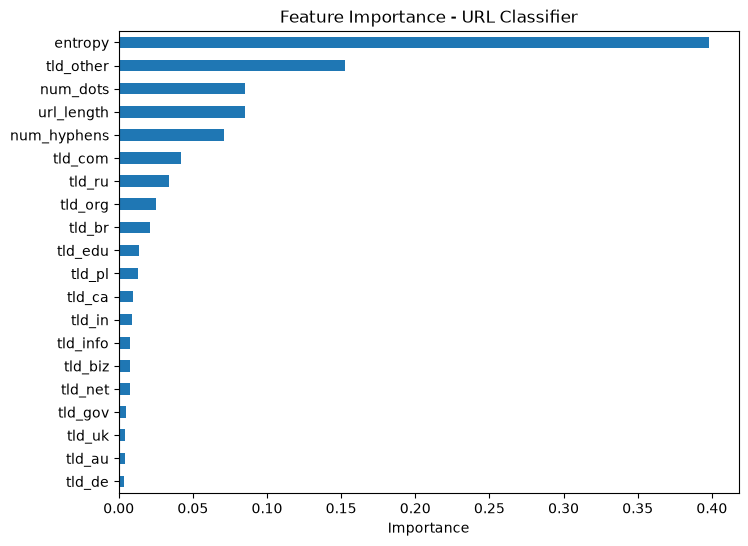

In [38]:
plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.xlabel('Importance')
plt.title('Feature Importance - URL Classifier')
plt.gca().invert_yaxis()
plt.show()

The confusion matrix show the model misses about 37% of acutal phishing URLs (false negatives), which is the most security-relevant error type. Feature importance shows that entropy is the most relied upon at about 40%, with unusual/rare TLDs grouped as "other" coming in second at 15%. This 